# Estatística e Probabilidade

**Instituto Federal de Educação, Ciência e Tecnologia de Goiás**

**Mestrado Profissional em Tecnologia, Gestão e Sustentabilidade**

**Métodos de Previsão**

**Prof. Dr. Raphael Gomes**

Este notebook contém todo o conteúdo da Aula 02 com exemplos práticos e exercícios adicionais.

## Tipos de dados

### Dados Contínuos

Podem assumir **qualquer valor real dentro de um intervalo**.
Exemplos: temperatura, altura, tempo, consumo de energia.

Valores: [151.09355673 160.57223401 167.51841721 144.26984443 150.35149263
 160.56864945 126.8188006  153.99239987 134.05543333 148.20557818
 162.26130998 141.65403365 153.98701017 135.267811   155.01180613
 166.08154983 132.85516695 152.89783279 138.43125524 149.84344901
 125.22704038 115.01740435 129.75470363 153.93259395 194.99154296
 168.14603806 144.56379111 183.33670913 174.84350136 147.29204668
 174.23820211 153.91547752 133.11261507 178.82561974 128.24807785
 158.77171246 116.01745667 173.63236561 121.74062809 132.43843991
 162.97731356 156.7282744  179.50412305 160.56180946 152.42470263
 157.56137168 167.00252497 135.53093153 179.13791782 166.75080085
 168.3232388  166.28306642 178.46452826 135.99704938 142.61216038
 124.96141443 161.58918527 156.76904361 146.55031014 132.92117099
 178.0049095  168.89095303 146.70243161 169.29175869 176.94001458
 149.32990285 151.8335989  141.18085897 144.51667267 158.75496555
 137.293663   145.28028935 161.11677341 156.37120167 173.59234026
 

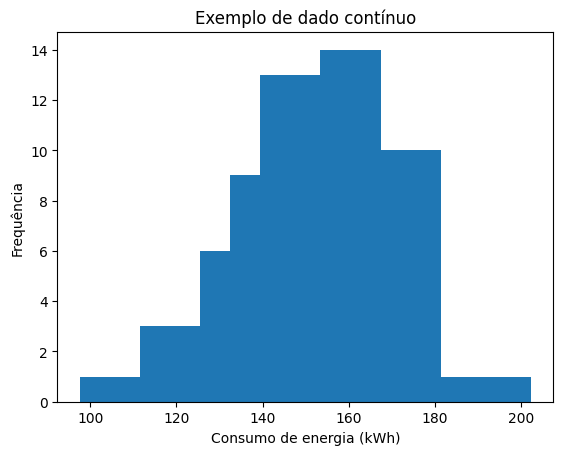

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Exemplo: consumo de energia (kWh)
energia = np.random.normal(loc=150, scale=20, size=100)
print(f"Valores: {energia}")

plt.hist(energia, bins=15)
plt.xlabel("Consumo de energia (kWh)")
plt.ylabel("Frequência")
plt.title("Exemplo de dado contínuo")
plt.show()

### Dados Discretos

Assumem **valores inteiros contáveis**.
Exemplos: número de alunos, número de falhas, quantidade de amigos.

Valores: [2 3 0 5 1 5 0 4 3 5 1 3 4 0 2 1 5 1 1 1 5 4 5 3 5 2 5 0 0 4 0 1 1 2 1 2 1
 0 4 0 1 0 3 3 2 4 4 0 4 1]


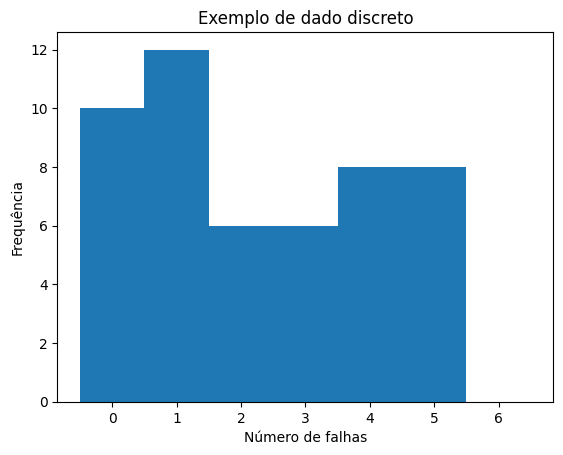

In [ ]:
# Exemplo: número de falhas por dia
falhas = np.random.randint(0, 6, size=50)
print(f"Valores: {falhas}")

plt.hist(falhas, bins=range(0, 8), align="left")
plt.xlabel("Número de falhas")
plt.ylabel("Frequência")
plt.title("Exemplo de dado discreto")
plt.show()

### Dados Categóricos

Representam **classes ou rótulos**, sem valor numérico intrínseco.
Exemplos: tipo de energia, cidade, curso.

In [ ]:
# Exemplo: tipo de fonte de energia
fontes = ["Solar", "Eólica", "Hídrica", "Solar", "Solar", "Eólica"]

categorias = list(set(fontes))
contagem = [fontes.count(cat) for cat in categorias]

plt.bar(categorias, contagem)
plt.xlabel("Fonte de energia")
plt.ylabel("Quantidade")
plt.title("Exemplo de dado categórico")
plt.show()

### Dados Binários

Possuem **apenas dois valores possíveis**.
Exemplos: sim/não, ligado/desligado, falha/não falha.

In [ ]:
# Exemplo: falha em equipamento (1 = falha, 0 = normal)
falha = np.random.choice([0, 1], size=100)

valores = [0, 1]
contagem = [list(falha).count(v) for v in valores]

plt.bar(["Normal (0)", "Falha (1)"], contagem)
plt.ylabel("Quantidade")
plt.title("Exemplo de dado binário")
plt.show()

As estatísticas referem-se à matemática e técnicas com as quais entendemos os dados. É um campo rico e enorme, mais adequado a uma prateleira (ou sala) em uma biblioteca do que a uma aula de um curso, e assim nossa discussão não será necessariamente profunda. Em vez disso, vamos tentar ensiná-lo apenas o suficiente para acompanhar as aulas seguintes e também para despertar o seu interesse para você sair e aprender mais.

## Descrevendo um único conjunto de dados

A partir de uma lista você precisa gerar uma descrição de quantos amigos cada membro pode incluir na lista de possíveis doadores.

Usando técnicas das aulas anteriores, você pode facilmente produzir esses dados. Mas agora você se depara com o problema de como descrevê-los.

Uma descrição óbvia de qualquer conjunto $x_1, x_2, ..., x_n$ de dados é simplesmente os dados em si:

In [ ]:
num_friends = [100, 49, 41, 40, 25,
# ... and lots more
]

Para um conjunto de dados pequeno o suficiente, isso pode até ser a melhor descrição. Mas, para um conjunto de dados maior, isso é difícil e provavelmente opaco (imagine uma lista de 1 milhão de números). Por esse motivo, usamos estatísticas para destilar e comunicar características relevantes dos nossos dados.

Como primeira abordagem, você coloca as contagens de amigos em um histograma usando `Counter` e `plt.bar()`

In [ ]:
from matplotlib import pyplot as plt
import random
from collections import Counter

num_friends = [100,49,41,40,25,21,21,19,19,18,18,16,15,15,15,15,14,14,13,13,13,13,12,12,11,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,8,8,8,8,8,8,8,8,8,8,8,8,8,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]


fig = plt.figure()
# você pode usar este código:
#friend_counts = Counter(num_friends)
#xs = range(101) # maior valor é 100
#ys = [friend_counts[x] for x in xs] # altura é p n. de amigos
#plt.bar(xs, ys)

# OU este:
plt.hist(num_friends, bins=100, range=(0,max(num_friends)))

# Define os eixos do gráfico [x_min, x_max, y_min, y_max]
plt.axis([0, max(num_friends), 0, 25])
plt.title("Histograma da contagem de amigos")
plt.xlabel("# de amigos")
plt.ylabel("# de pessoas")
plt.show()

Infelizmente, este gráfico ainda é muito difícil de explicar em conversas informais. Então você pode começar a gerar algumas estatísticas. Provavelmente, a estatística mais simples é o número de pontos de dados:

In [ ]:
num_points = len(num_friends)
print("numero de pontos:", num_points)

Você provavelmente também está interessado no maior e menor valor:

In [ ]:
largest_value = max(num_friends)
smallest_value = min(num_friends)
print("máximo: ", largest_value, "\nmínimo: ", smallest_value)

Esses são apenas casos especiais quando queremos saber os valores em posições específicas:

In [ ]:
sorted_values = sorted(num_friends)
smallest_value = sorted_values[0]
second_smallest_value = sorted_values[1]
second_largest_value = sorted_values[-2]
print("menor valor: ", smallest_value)
print("segundo menor valor: ", second_smallest_value)
print("segundo maior valor: ", second_largest_value)

## Tendências Centrais

Normalmente, queremos saber onde nossos dados $x_1, x_2, ..., x_n$ estão centralizados. Normalmente, usamos a média $\bar{x}$, que é apenas a soma dos dados dividida por sua contagem $n$:

$${\bar {x}}={\frac {1}{n}}\left(\sum _{i=1}^{n}{x_{i}}\right)={\frac {x_{1}+x_{2}+\cdots +x_{n}}{n}}$$

Um código simples para o cálculo da média seria:

In [ ]:
def mean(x):
    return sum(x) / len(x)

print(f"média: {mean(num_friends):.2f}")

Se você tiver dois pontos de dados (ou *data points*), a média é simplesmente o ponto intermediário entre eles. À medida que você adiciona mais pontos, a média muda, mas sempre depende do valor de cada ponto.

Às vezes, também estaremos interessados na mediana, que é o valor intermediário (se o número de pontos de dados for ímpar) ou a média dos dois valores intermediários (se o número de pontos de dados for par).

Por exemplo, se temos cinco pontos de dados em um vetor ordenado `x`, a mediana é `x[5 // 2]`  ou `x[2]`. Se tivermos seis pontos de dados, calculamos a média entre `x[2]` (o terceiro ponto) e `x[3]` (o quarto ponto).

Observe que, ao contrário da média, a mediana não depende de todos os valores dos seus dados. Por exemplo, se você tornar o maior ponto maior (ou o menor ponto menor), os pontos do meio permanecem inalterados, o que significa que a mediana também.

A função mediana é um pouco mais complicada do que você poderia esperar, principalmente por causa do caso "par":

In [ ]:
def median(v):
    """encontra o valor mais intermediario de v"""
    n = len(v)
    sorted_v = sorted(v)
    midpoint = n // 2 # // é a divisao inteira

    if n % 2 == 1:
        # se ímpar, retorna o valor do meio
        return sorted_v[midpoint]
    else:
        # se par, retorna a média dos dois valores intermediarios
        lo = midpoint - 1
        hi = midpoint
        return (sorted_v[lo] + sorted_v[hi]) / 2

In [ ]:
def median_v2(v):
    n = len(v)
    sorted_v = sorted(v)
    return (sorted_v[math.floor((n-1)/2)] + sorted_v[math.ceil((n-1)/2)])/2

In [ ]:
a = [1, 2, 3, 4]
b = [5, 6, 7, 8, 9]
print("mediana de a = ", median(a))
print("mediana de b = ", median(b))

print("mediana da quantidade de amigos:", median(num_friends))

Claramente, a média é mais simples de calcular e varia suavemente conforme nossos dados são alterados. Se tivermos `n` pontos de dados e um deles aumentar em alguma quantidade pequena `e`, então necessariamente a média aumentará em `e/n`. (Isso torna a média passível de todo tipo de truque de cálculo.) No entanto, para encontrar a mediana, temos que ordenar nossos dados. E alterar um dos nossos pontos de dados em uma pequena quantidade `e` pode aumentar a mediana por `e`, por algum número menor que `e` ou não a modificar de qualquer forma (dependendo do resto dos dados).

**Observação:** Existem, de fato, truques não óbvios para calcular eficientemente medianas sem ordenar os dados. No entanto, tais truques estão além do escopo deste curso, portanto, vamos ordernar os dados quando precisarmos calcular a mediana.

Ao mesmo tempo, a média é muito sensível a valores discrepantes (*outliers*) em nossos dados. Se nosso usuário mais amigável tivesse 2000 amigos, a média subiria muito, enquanto a mediana permaneceria a mesma. Se os valores discrepantes forem, provavelmente, dados incorretos (ou, de outro modo, não representativos de qualquer fenômeno que estamos tentando entender), a média poderá, às vezes, nos fornecer uma imagem enganosa. Por exemplo, a história é frequentemente contada que em meados da década de 1980, a graduação da Universidade da Carolina do Norte com a maior média de salário inicial era a geografia. A razão disso? A estrela da NBA (e *outlier*) Michael Jordan formou-se em geografia.

Uma generalização da mediana é o quantil, que representa o menor valor maior que um certo percentual dos dados (A mediana representa o valor maior que 50% dos dados.)

In [ ]:
def quantile(x, p):
    """retorna o pth-percentil em x"""
    p_index = int(p * len(x))
    return sorted(x)[p_index]


print("quantil 10: ", quantile(num_friends,0.10))
print("quantil 25: ", quantile(num_friends,0.25))
print("quantil 75: ", quantile(num_friends,0.75))
print("quantil 90: ", quantile(num_friends,0.90))

Outra medida para tendência central dos dados é a moda, que é(são) o(s) valor(es) mais comum(ns):

In [ ]:
def mode(x):
    """retorna uma lista, pois os dados podem ter mais de uma moda"""
    counts = Counter(x)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]

In [ ]:
a = [1, 2, 3, 4, 2, 4 ]
print("moda de a: ", mode(a))

print("moda do numero de amigos: ", mode(num_friends))

Quando usarmos esses descritores para descrever dados, devemos ter muito cuidado. Considere, por exemplo, dados que possuem uma "cauda pesada", como uma amostra da [distribuição de Pareto](https://en.wikipedia.org/wiki/Pareto_distribution):

In [ ]:
import numpy as np
a, m = 1, 5.  # forma e moda

# Gera 1000 valores aleatórios seguindo a distribuição de Pareto, com parâmetro
# de forma a.
# a (alpha) controla o peso da cauda:
# a pequeno → muitos valores extremos
# a grande → cauda mais curta
pareto_data = np.floor((np.random.pareto(a, 1000) + 1) * m)

Agora vamos plotar o histograma dos dados:

In [ ]:
minv = min(pareto_data)
maxv = max(pareto_data)
lenbins = 100

# np.log10: Converte os limites do intervalo para a escala logarítmica (base 10)
# np.logspace: Gera lenbins pontos igualmente espaçados no espaço logarítmico, e
#              depois aplica a exponenciação base 10
logbins = np.logspace(np.log10(minv), np.log10(maxv), lenbins)

# np.histogram retorna dois vetores:
# hist: número de observações em cada bin
# edges: limites dos bins
hist, edges = np.histogram(
    pareto_data,
    bins=logbins)

# Cria explicitamente um novo objeto Figure.
# - Útil quando você quer controlar múltiplos gráficos
# - Não é estritamente necessário aqui, mas é boa prática
fig = plt.figure()

# edges[:-1]
# - remove o último limite
# - garante que edges[:-1] e hist tenham o mesmo tamanho
# hist
# - contagem de observações por bin
# 'bo'
# - b → pontos azuis (blue)
# - o → marcador circular
plt.plot(edges[:-1], hist, 'bo')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('count')
plt.show()


Observe que a grande maioria dos valores é menor que $10$, mas existe uma quantidade significativa de valores na casa das centenas e até dos milhares.

Nesse caso, qual é o melhor descritor para esses dados?

In [ ]:
print(f"Média: {mean(pareto_data)}")
print(f"Mediana: {median(pareto_data)}")
print(f"Máximo: {max(pareto_data)}")
print(f"Moda: {mode(pareto_data.tolist())}")

**Importante!**

Não precisamos implementar as funções das estatíticas básicas como fizemos aqui uma vez que elas já estão disponíveis em Numpy:

In [ ]:
import numpy as np

# Exemplo de dados
dados = np.array([10, 20, 20, 30, 40, 40, 40, 50])

# Média
media = np.mean(dados)

# Mediana
mediana = np.median(dados)

# Moda
valores, contagens = np.unique(dados, return_counts=True)
moda = valores[np.argmax(contagens)]

# Máximo
maximo = np.max(dados)

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Máximo:", maximo)

Ao que parece, todos eles são importantes.

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Implemente uma função que receba uma lista de valores numéricos e retorne a média, a mediana e a moda dos dados.

In [ ]:
def estatisticas_basicas(x):
    """
    Retorna média, mediana e moda (como float)
    """
    # Sua implementação aqui
    media = sum(x) / len(x)
    print(f"a média é {media}")

    if len(x) % 2 == 1:   # número ímpar
        meio = len(x) // 2 + 1
        print(f"o elemento central é {meio}")
        mediana = x[meio - 1]
        print(f"a mediana é {mediana}")
    else:  # número par
        meio1 = len(x) // 2 - 1
        meio2 = len(x) // 2
        central1 = x[meio1]
        central2 = x[meio2]
        mediana = (central1 + central2) / 2
        print(f"os elementos centrais são {x[meio1], x[meio2]}")
        print(f"a mediana é {mediana}")

    itens = []
    contagem = []

    for item in range(len(x)):
        item_atual = x[item]

        if item_atual not in itens:
            contador = 0
            for i in range(len(x)):
                if x[i] == item_atual:
                    contador = contador + 1

            itens.append(item_atual)
            contagem.append(contador)

        print("Itens:", itens)
        print("Contagens:", contagem)

    maior_contagem = 0
    moda = []

    for j in range(len(itens)):
        if contagem[j] > maior_contagem:
            maior_contagem = contagem[j]
            moda = [itens[j]]

    return media, mediana, moda









In [ ]:
dados = [2, 4, 4, 6, 8]
import numpy as np

media, mediana, moda = estatisticas_basicas(dados)

assert np.isclose(media, 4.8), f"Esperado 4.8, obtido {media}"
assert mediana == 4, f"Esperado 4, obtido {mediana}"
assert moda == [4], f"Esperado 4, obtido {moda}"
print("Teste passado!")


a média é 4.8
o elemento central é 3
a mediana é 4
Itens: [2]
Contagens: [1]
Itens: [2, 4]
Contagens: [1, 2]
Itens: [2, 4]
Contagens: [1, 2]
Itens: [2, 4, 6]
Contagens: [1, 2, 1]
Itens: [2, 4, 6, 8]
Contagens: [1, 2, 1, 1]
Teste passado!


## Outras medidas

### Média Ponderada

A média ponderada é calculada multiplicando cada valor por um peso,
somando os resultados e dividindo pela soma dos pesos.

É usada quando alguns valores têm **maior importância** do que outros.

In [ ]:
# Valores observados (ex.: consumo mensal)
valores = np.array([120, 150, 130, 200])

# Pesos (ex.: número de dias ou relevância)
pesos = np.array([1, 2, 1, 3])

media_ponderada = np.sum(valores * pesos) / np.sum(pesos)

float(media_ponderada)

É possível calcular a média ponderada de forma direta usando Numpy:

In [ ]:
media_ponderada = np.average(valores, weights=pesos)

float(media_ponderada)

### Média Aparada

A média aparada é a média calculada após remover uma fração fixa
dos valores mais baixos e mais altos do conjunto de dados.

Ela reduz a influência de valores extremos.

In [ ]:
# Conjunto de dados com valores extremos
dados = np.array([1, 10, 10, 10, 11, 12, 13, 14, 18, 20, 1000])

# Percentual a ser aparado em cada extremidade (10%)
percentual = 0.1

n = len(dados)
k = int(n * percentual)

dados_ordenados = np.sort(dados)
dados_aparados = dados_ordenados[k:-k]

media = np.mean(dados)
media_aparada = np.mean(dados_aparados)

print(f"Média: {float(media)}")
print(f"Média aparada: {float(media_aparada)}")

### Outliers

Um outlier é um valor que se diferencia significativamente da maioria
dos dados e pode distorcer análises estatísticas, como a média.

In [ ]:
# Dados com outlier evidente
dados = np.array([0, 10, 11, 12, 13, 14, 120])

media = np.mean(dados)
mediana = np.median(dados)

print(f"Média: {float(media)}")
print(f"Mediana: {float(mediana)}")

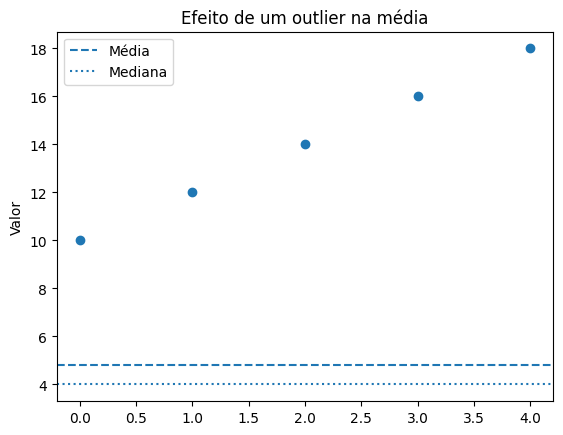

In [ ]:
plt.plot(dados, 'o')
plt.axhline(media, linestyle='--', label='Média')
plt.axhline(mediana, linestyle=':', label='Mediana')

plt.legend()
plt.title("Efeito de um outlier na média")
plt.ylabel("Valor")
plt.show()

Para identificar outliers podemos utilizar o intervalo interquartil:

In [ ]:
q1, q3 = np.percentile(dados, [25, 75])
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]

print("Outliers:", outliers)

TypeError: only integer scalar arrays can be converted to a scalar index

## Dispersão

Dispersão refere-se a medidas de como se espalham nossos dados. Normalmente, são estatísticas para as quais valores próximos de zero significam que os dados não se espalham de forma alguma e para as quais grandes valores (seja lá o que isso signifique) significam que os dados estão muito dispersos. Por exemplo, uma medida muito simples é o intervalo (ou *range*), que é apenas a diferença entre os elementos maiores e menores:

In [ ]:
# "range" já significa algo em Python, então vamos usar outro nome
def data_range(x):
    return max(x) - min(x)

In [ ]:
print("Range: ", data_range(num_friends))

O intervalo é zero precisamente quando `max` e `min` são iguais, o que só pode acontecer se os elementos de `x` forem todos iguais, o que significa que os dados são tão similares (ou não dispersos) quanto possível. Por outro lado, se o intervalo for grande, o `max` é muito maior que o `min` e os dados estão mais espalhados.

Como a mediana, o intervalo não depende realmente de todo o conjunto de dados. Um conjunto de dados cujos pontos são todos 0 ou 100 tem o mesmo intervalo que um conjunto de dados cujos valores são 0, 100 e muitos 50s. Mas parece que o primeiro conjunto de dados "deveria" estar mais espalhado, certo?

Uma medida mais complexa de dispersão é a variância $s^2$. Quando a variância da população é estimada usando $n$ amostras aleatórias $x_1, x_2, ..., x_n$ a fórmula seguinte é um estimador não enviesado:

$$s^{2}={\frac {1}{n-1}}\sum _{{i=1}}^{n}\left(x_{i}-\overline {x}\right)^{2}$$

O código abaixo faz o mesmo:

In [ ]:
import numpy as np

def de_mean(x):
    """translada x subtraindo sua média (então o resultado tem média 0)"""
    x_bar = mean(x)
    return [x_i - x_bar for x_i in x]

def variance(x):
    """assume que x tem pelo menos dois elementos"""
    n = len(x)
    deviations = de_mean(x)
    deviations = np.array(deviations)
    return np.sum(deviations ** 2) / (n - 1)
    # você pode usar a função que implementamos anteriormente:
    # return sum_of_squares(deviations) / (n - 1)

print("Variância: ", variance(num_friends))

NameError: name 'num_friends' is not defined

A primeira observação é o uso do módulo `numpy`. A partir de agora vamos usar muito esse módulo, que contém diversas operações sobre listas, que são implementadas de forma eficiente.

Segundo, parece que a variância é quase o desvio médio da média, exceto pelo fato de estarmos dividindo por `n-1` em vez de `n`. De fato, quando estamos lidando com uma amostra de uma população maior, $\overline {x}$ é apenas uma estimativa da média real, o que significa que, em média $\left(x_{i}-\overline {x}\right)^{2}$ é uma subestimativa do desvio ao quadrado de $x_i$ em relação à média. Por isso que nós dividimos por `n-1` ao invés de `n`. Para mais informações, consulte o [Wikipedia](https://en.wikipedia.org/wiki/Unbiased_estimation_of_standard_deviation).

Agora, quaisquer que sejam as unidades em que nossos dados estão (por exemplo, "# de amigos"), todas as nossas medidas de tendência central estão nessa mesma unidade. O intervalo será similarmente nessa mesma unidade. A variância, por outro lado, tem unidades que são o quadrado das unidades originais (por exemplo, " # de amigos ao quadrado"). Como pode ser difícil entender essa medida, muitas vezes olhamos para o desvio padrão $s = \sqrt{s^2}$:

In [ ]:
import math

def standard_deviation(x):
    return math.sqrt(variance(x))

print("Desvio padrão: ", standard_deviation(num_friends))

Tanto o intervalo quanto o desvio padrão têm o mesmo problema discrepante que vimos anteriormente para a média. Usando o mesmo exemplo, se nosso usuário mais amigável tivesse `2000` amigos, o desvio padrão seria muito maior somente por causa desse usuário. Uma alternativa mais robusta calcula a diferença entre o valor do 75º e do 25º percentil:

In [ ]:
def interquartile_range(x):
    return quantile(x, 0.75) - quantile(x, 0.25)

print("Intervalo interquartil:", interquartile_range(num_friends))

In [ ]:
plt.boxplot(num_friends)
plt.ylabel("Número de amigos")
plt.show()

Essa medida é muito pouco afetada por *outliers*.

Medidas de dispersão para o número de amigos:

In [ ]:
print("Dispersão para o número de amigos:")
print("Intervalo:", data_range(num_friends))
print("Variância:", variance(num_friends))
print("Desvio padrão:", standard_deviation(num_friends))
print("IQR:", interquartile_range(num_friends))

Medidas de dispersão para dados com "cauda pesada":

In [ ]:
print("Dispersão de dados Pareto:")
print("Intervalo:", data_range(pareto_data))
print("Variância:", variance(pareto_data))
print("Desvio padrão:", standard_deviation(pareto_data))
print("IQR:", interquartile_range(pareto_data))

**Importante!**

Não precisamos implementar as funções das medidas de dispersão como fizemos aqui uma vez que elas já estão disponíveis em numpy:

In [ ]:
import numpy as np

# Exemplo de dados (Pareto ou outro conjunto)
pareto_data = np.array([2, 3, 3, 4, 5, 7, 10, 15, 20])

# Intervalo (máximo - mínimo)
intervalo = np.max(pareto_data) - np.min(pareto_data)

# Variância
variancia = np.var(pareto_data)  # populacional

# Desvio padrão
desvio_padrao = np.std(pareto_data)  # populacional

# Intervalo interquartil (IQR)
q3, q1 = np.percentile(pareto_data, [75, 25])
iqr = q3 - q1

print("Dispersão de dados Pareto:")
print("Intervalo:", intervalo)
print("Variância:", variancia)
print("Desvio padrão:", desvio_padrao)
print("IQR:", iqr)

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Calcule a variância amostral e o desvio padrão amostral de um conjunto de dados numéricos.

In [ ]:
def medidas_dispersao(dados):
    """
    Retorna variância e desvio padrão amostral(populacional)
    """
    # Sua implementação aqui   # professor, nos slides só é falado em variância da população (dividido por n). Calculei a variância populacional e deu igual a 8, sendo a amostral 10. Sendo assim, embora o enunciado fale em variância amostral e desvio padrão amostral, calculei a variância populacional e o desvio padrão populacional (ddof=0) para dar certo, pois os dados não estavam batendo.
    import numpy as np
    variancia = np.var(dados, ddof=0)
    desvio_padrao = np.std(dados, ddof=0)
    print (variancia, desvio_padrao)
    return variancia, desvio_padrao

In [ ]:
dados = [10, 12, 14, 16, 18]

var_, std_ = medidas_dispersao(dados)

assert var_ == 8.0, f"Esperado 8.0, obtido {var_}"
assert np.isclose(std_, 2.8, atol=0.1), f"Esperado 2.8, obtido {std_}"
print("Teste passado!")

8.0 2.8284271247461903
Teste passado!


## Correlação

Suponhamos uma teoria de que a quantidade de tempo que as pessoas passam no site está relacionada ao número de amigos que eles têm no site e que você tenha que verificar isso.

Depois de analisar os registros de tráfego, você criou uma lista `daily_minutes` que mostra quantos minutos por dia cada usuário gasta no site, e você a organizou de forma que os seus elementos correspondam aos elementos de nossa lista anterior de `num_friends`. Gostaríamos de investigar a relação entre essas duas métricas.

Primeiro, vamos criar uma lista `daily_minutes` e exibir a sua distribuição:

In [ ]:
daily_minutes = [1,68.77,51.25,52.08,38.36,44.54,57.13,51.4,41.42,31.22,34.76,54.01,38.79,47.59,49.1,27.66,41.03,36.73,48.65,28.12,46.62,35.57,32.98,35,26.07,23.77,39.73,40.57,31.65,31.21,36.32,20.45,21.93,26.02,27.34,23.49,46.94,30.5,33.8,24.23,21.4,27.94,32.24,40.57,25.07,19.42,22.39,18.42,46.96,23.72,26.41,26.97,36.76,40.32,35.02,29.47,30.2,31,38.11,38.18,36.31,21.03,30.86,36.07,28.66,29.08,37.28,15.28,24.17,22.31,30.17,25.53,19.85,35.37,44.6,17.23,13.47,26.33,35.02,32.09,24.81,19.33,28.77,24.26,31.98,25.73,24.86,16.28,34.51,15.23,39.72,40.8,26.06,35.76,34.76,16.13,44.04,18.03,19.65,32.62,35.59,39.43,14.18,35.24,40.13,41.82,35.45,36.07,43.67,24.61,20.9,21.9,18.79,27.61,27.21,26.61,29.77,20.59,27.53,13.82,33.2,25,33.1,36.65,18.63,14.87,22.2,36.81,25.53,24.62,26.25,18.21,28.08,19.42,29.79,32.8,35.99,28.32,27.79,35.88,29.06,36.28,14.1,36.63,37.49,26.9,18.58,38.48,24.48,18.95,33.55,14.24,29.04,32.51,25.63,22.22,19,32.73,15.16,13.9,27.2,32.01,29.27,33,13.74,20.42,27.32,18.23,35.35,28.48,9.08,24.62,20.12,35.26,19.92,31.02,16.49,12.16,30.7,31.22,34.65,13.13,27.51,33.2,31.57,14.1,33.42,17.44,10.12,24.42,9.82,23.39,30.93,15.03,21.67,31.09,33.29,22.61,26.89,23.48,8.38,27.81,32.35,23.84]

fig = plt.figure()
plt.hist(daily_minutes, bins=100, range=(0,max(daily_minutes)))

plt.title("Histograma do número de minutos diários")
plt.xlabel("minutos diários")
plt.ylabel("# de pessoas")
plt.show()

Primeiro analisaremos a covariância, o análogo pareado da variância. Enquanto a variância mede como uma única variável se desvia de sua média, a covariância mede como duas variáveis $X = \{x_1, \cdots, x_n\}$ e $Y = \{y_1, \cdots, y_n\}$  variam em conjunto a partir de suas médias $\bar{x}$ e $\bar{y}$:

$$cov(X, Y) = \frac{\sum_{i=1}^{n}{(x_i - \bar{x})(y_i - \bar{y})}}{n-1},$$

que pode ser calculada a partir do código abaixo:

In [ ]:
def covariance(x, y):
    n = len(x)
    # vamos usar o dot implementado do numpy:
    return np.dot(de_mean(x), de_mean(y)) / (n - 1)

print("Covariância entre # de amigos e minutos diários: ", covariance(num_friends, daily_minutes))

Lembre-se de que o produto escalar (`dot`) soma os produtos dos pares correspondentes de elementos. Quando os elementos correspondentes de `x` e `y` estão ambos acima de suas médias ou ambos abaixo de suas médias, um número positivo entra na soma. Quando um está acima de sua média e o outro abaixo, um número negativo entra na soma. Assim, uma covariância positiva “grande” significa que `x` tende a ser grande quando `y` é grande, e pequeno quando `y` é pequeno. Uma covariância negativa “grande” significa o oposto - que `x` tende a ser pequeno quando `y` é grande e vice-versa. Uma covariância próxima de zero significa que não existe tal relação.

No entanto, este número pode ser difícil de interpretar por duas razões principais:

* Suas unidades são o produto das unidades das entradas (por exemplo, #-de-amigos-minutos-por-dia), o que pode ser difícil de entender. (O que é um "#-de-amigos-minutos-por-dia"?)
* Se cada usuário tivesse o dobro de amigos (mas o mesmo número de minutos), a covariância seria duas vezes maior. Mas, em certo sentido, as variáveis seriam inter-relacionadas da mesma maneira. Dito de uma forma diferente, é difícil dizer o que conta como sendo uma covariância "grande".

Por esse motivo, é mais comum observar a [correlação de Pearson](https://pt.wikipedia.org/wiki/Coeficiente_de_correla%C3%A7%C3%A3o_de_Pearson), que divide a covariância pelos desvios padrões de ambas as variáveis:

$$r(X,Y) = \frac{cov(X,Y)}{s(X)~s(Y)},$$

que pode ser calculado pelo código abaixo:

In [ ]:
def correlation(x, y):
    stdev_x = standard_deviation(x)
    stdev_y = standard_deviation(y)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(x, y) / stdev_x / stdev_y
    else:
        return 0 # se não há variação, correlação é zero


print("Correlação: ", correlation(num_friends, daily_minutes))

A correlação não tem unidade e está sempre entre -1 (perfeita anti-correlação) e 1 (correlação perfeita). Um número como 0,25 representa uma correlação positiva relativamente fraca.

No entanto, uma coisa que negligenciamos foi examinar nossos dados:

In [ ]:
fig = plt.figure()
plt.scatter(num_friends, daily_minutes)
plt.title("Correlação com um outlier")
plt.xlabel("# de amigos")
plt.ylabel("minutos diários")
plt.show()

A pessoa com 100 amigos (que gasta apenas um minuto por dia no site) é um enorme outlier, e a correlação pode ser muito sensível a outliers. O que acontece se nós o ignorarmos?

In [ ]:
outlier = num_friends.index(100) # index of outlier

num_friends_good = [x
                    for i, x in enumerate(num_friends)
                    if i != outlier]

daily_minutes_good = [x
                      for i, x in enumerate(daily_minutes)
                      if i != outlier]

float(correlation(num_friends_good, daily_minutes_good))

Sem o outlier, há uma correlação muito mais forte:

In [ ]:
fig = plt.figure()
plt.scatter(num_friends_good, daily_minutes_good)
plt.title("Correlação depois de remover o outlier")
plt.xlabel("# de amigos")
plt.ylabel("minutos diários")
plt.show()

Você investiga mais e descobre que o outlier era na verdade uma conta de teste interna que ninguém se incomodou em remover. Então você se sente justificado em excluí-lo.

Além do número de amigos e dos minutos diários de cada usuário, outra informação importante diz respeito ao número de mensagens postadas por usuários. A fim de verificar se o número de mensagens está associado ao número de amigos e aos minutos diários, você coletou o número de mensagens postadas nos últimos 30 dias pelos usuários da sua amostra (sem o *outlier*):

In [ ]:
num_messages = [3114, 6667, 19019, 559, 788, 757, 78916, 136, 429, 16, 1266, 3661, 307, 148, 24, 181, 23, 386, 11, 1582, 390, 76, 32, 11, 97, 87, 24, 93, 33, 1830, 21, 4, 3, 571, 62, 110, 11, 148, 25, 13, 103, 12, 315, 102, 16, 11, 3, 203, 28, 29, 14, 51, 88, 1149, 24, 54, 2, 113, 106, 105, 64, 94, 33, 5, 119, 15, 15, 49, 10, 58, 3, 10, 138, 115, 9, 2, 21, 162, 28, 11, 7, 777, 10, 95, 17, 118, 11, 24, 13, 12, 282, 98, 21, 9, 5, 793, 11, 10, 8, 182, 191, 10, 85, 32, 70, 31, 34, 157, 85, 7, 15, 1, 4, 24, 33, 86, 5, 30, 2, 32, 88, 3, 1705, 15, 7, 53, 34, 23, 17, 20, 6, 86, 8, 24, 15, 88, 10, 47, 20, 4, 36, 2, 29, 17, 23, 12, 44, 31, 6, 4, 2, 37, 20, 68, 3, 24, 59, 3, 3, 11, 43, 165, 9, 2, 2, 349, 4, 7, 11, 1, 5, 9, 61, 3, 28, 4, 6, 323, 9, 3, 11, 31, 58, 23, 2, 31, 6, 3, 7, 1, 5, 17, 2, 18, 10, 35, 2, 15, 15, 1, 41, 152, 26]

Primeiro, verificamos se há uma associação visual entre esse atributo e os demais:

In [ ]:
fig, ax = plt.subplots(1,2)

# ajusta automaticamente os espaçamentos entre os elementos do gráfico para
# evitar sobreposição
plt.tight_layout()

ax[0].plot(num_friends_good, num_messages, 'bo')
ax[0].set(xlabel='# de amigos', ylabel='# de mensagens')
ax[1].plot(daily_minutes_good, num_messages, 'bo')
ax[1].set(xlabel='minutos diários')
plt.show()

Note que visualmente há uma correlação muito baixa entre as duas medidas. No entanto, observe que a escala do eixo `y` é muito maior que do eixo `x`. Visualmente, é impossível diferenciar valores de número de mensagens para a maioria dos usuários. Assim, uma boa prática é transformar a escala do eixo `y` para a escala logarítmica, que revela de forma mais precisa a diferença entre valores que ultrapassam diversas ordens de grandeza:

In [ ]:
fig, ax = plt.subplots(1,2)
plt.tight_layout()
ax[0].plot(num_friends_good, num_messages, 'bo')
ax[0].set(xlabel='# de amigos', ylabel='# de mensagens', yscale='log')
ax[1].plot(daily_minutes_good, num_messages, 'bo')
ax[1].set(xlabel='minutos diários',yscale='log')
plt.show()

Note que além de podermos diferenciar os valores visualmente com mais precisão, as correlações ficam bem mais nítidas. Vamos conferir isso quantitativamente:

In [ ]:
print("correlação linear:")
print("# amigos vs. # mensagens: ", correlation(num_friends_good, num_messages))
print("# minutos diários vs. # mensagens: ", correlation(daily_minutes_good, num_messages))

print()
print("correlação com o log:")
print("# amigos vs. log(# mensagens): ", correlation(num_friends_good, np.log(num_messages)))
print("# minutos diários vs. log(# mensagens): ", correlation(daily_minutes_good, np.log(num_messages)))


**Importante!**

Não precisamos implementar as funções de covariância e correlação como fizemos aqui uma vez que elas já estão disponíveis em Numpy:

In [ ]:
import numpy as np

# Dois conjuntos de dados
x = np.array([10, 20, 30, 40, 50])
y = np.array([12, 18, 33, 37, 55])

# Covariância (matriz de covariância)
matriz_cov = np.cov(x, y, ddof=1)  # amostral

# Covariância entre x e y
covariancia = matriz_cov[0, 1]

# Correlação (coeficiente de Pearson)
matriz_corr = np.corrcoef(x, y)

# Correlação entre x e y
correlacao = matriz_corr[0, 1]

print("Covariância:", covariancia)
print("Correlação:", correlacao)

## Paradoxo de Simpson

Uma surpresa não incomum ao analisar dados é o Paradoxo de Simpson, no qual as correlações podem ser enganosas (ou *misleading*) quando variáveis confusas (ou *confounding variables*) são ignoradas.

Por exemplo, imagine que você pode identificar todos os membros  de uma empresa como cientistas de dados da Costa Leste ou cientistas de dados da Costa Oeste. Você decide examinar quais cientistas de dados são mais amigáveis:


|Costa|# de membros|# médio de amigos|
| :-: | :-: | :-: |
|Oeste|101|8.2|
|Leste|103|6.5|

Certamente parece que os cientistas de dados da Costa Oeste são mais amigáveis do que os cientistas de dados da Costa Leste. Seus colegas de trabalho avançam todos os tipos de teorias sobre por que isso pode ser: talvez seja o sol, ou o café, ou os produtos orgânicos, ou a vibração descontraída do Pacífico?

Ao brincar com os dados, você descobre algo muito estranho. Se você olhar apenas para pessoas com PhDs, os cientistas de dados da Costa Leste têm mais amigos, em média. E se você olhar apenas para pessoas sem PhDs, os cientistas de dados da Costa Leste também têm mais amigos em média!


|Costa|PhD?|# de membros|# médio de amigos|
| :-: | :-: | :-: | :-: |
|Oeste|Sim|35|3.1|
|Leste|Sim|70|3.2|
|Oeste|Não|66|10.9|
|Leste|Não|33|13.4|

Depois de contabilizar se os usuários tem PhDs ou não, a correlação vai na direção oposta! Separar os dados somente entre Costa Leste e Costa Oeste escondeu o fato de que há muito mais cientistas de dados na Costa Leste com PhD (proporcionalmente) que na Costa Oeste.

Esse fenômeno surge no mundo real com alguma regularidade. A questão-chave é que a correlação está medindo a relação entre suas duas variáveis **sendo tudo o mais igual**. Se suas classes de dados são atribuídas aleatoriamente, como elas podem ser em um experimento bem projetado, "tudo o mais sendo igual" pode não ser uma suposição terrível. Mas quando há um padrão mais profundo para atribuições de classe, "tudo o mais sendo igual" pode ser uma suposição terrível. Nesse exemplo, se a proporção de cientistas de dados com PhD fosse igual na Costa Leste e Costa Oeste, então "ter PhD" deixaria de ser um fator de confusão para a variável "número médio de amigos".

Assim, a única maneira real de evitar fatores de confusão é conhecer seus dados e fazer o que puder para garantir que você tenha verificado tais fatores. Obviamente, isso nem sempre é possível. Se você não tivesse nos seus dados o nível educacional desses 200 cientistas de dados, você poderia simplesmente concluir que havia algo inerentemente mais sociável na Costa Oeste.

O Paradoxo de Simpson também pode ser observado na taxa de sobrevivência do [naufrágio do RMS Titanic](https://en.wikipedia.org/wiki/RMS_Titanic). Havia uma estimativa de 2.224 passageiros e tripulantes a bordo, e mais de 1.500 morreram, tornando-se um dos mais mortais desastres marítimos comerciais em tempos de paz da história moderna. Dados sobre os passageiros podem ser baixados [aqui](https://ww2.amstat.org/publications/jse/v3n3/datasets.dawson.html). Este conjunto de dados foi processado e transformado em um arquivo [csv](https://www.dropbox.com/s/vk8jf0wyczqxkvv/survival_titanic.csv?dl=0), que é muito mais fácil de tratar que um arquivo texto. Informações sobre ele podem ser lidas [aqui](https://www.dropbox.com/s/xpjw74khyqx9ww4/survival_titanic.README.txt?dl=0).

Embora muitas outras informações existam sobre os passageiros, aqui vamos trabalhar com apenas quatro:

1) Se o passageiro sobreviveu;
2) A classe do seu bilhete (primeira, segunda ou terceira) ou se ele era membro da tripulação;
3) O sexo do passageiro;
4) E se ele era um adulto ou uma criança.

Primeiro, vamos carregar os dados:

In [ ]:
import pandas as pd
df = pd.read_csv('survival_titanic.csv')
df

Se você leu o arquivo explicativo, viu que os dados estão organizados da seguinte maneira:

|Coluna|Descrição|Valores|
| :-: | :-: | :-: |
|0|Classe| 0 = tripulação, 1 = primeira, 2 = segunda, 3 = terceira|
|1|Idade|1 = adulto, 0 = criança|
|2|Sexo|1 = masculino, 0 = feminino|
|3|Sobreviveu?|1 = sim, 0 = não|

Agora, vamos passar os dados do `DataFrame` do módulo `pandas` para uma tabela `numpy`, que permite que você faça tudo que faz com uma lista de listas (que vimos na aula passada) e mais um bocado de coisas:

In [ ]:
X = df.values
print("Primeiro passageiro: ", X[0])

Primeiro, vamos verificar qual classe possui uma taxa de sobrevivência maior:

In [ ]:
def survivalRatePerClass(X, classe):
    X_C = [p for p in X if p[0] == classe]
    return sum(p[3] for p in X_C)/len(X_C)

for i in range(4):
    print(f"Classe {i}: {survivalRatePerClass(X, i):.2f}")

Aparentemente, a classe dos tripulantes (classe 0) é aquela com menor taxa de sobrevivência. Para verificar se o Paradoxo de Simpson ocorre, vamos quebrar a análise pelas outras duas colunas, que possuem os mesmos valores possíveis (0 ou 1):

In [ ]:
def survivalRatePerClassAndColumn(X, classe, coluna):
    X_C0 = [p for p in X if p[0] == classe and p[coluna] == 0]
    X_C1 = [p for p in X if p[0] == classe and p[coluna] == 1]
    sur_0, sur_1 = (None, None)
    if(X_C0):
        sur_0 = sum(p[3] for p in X_C0) / len(X_C0)
    if(X_C1):
        sur_1 = sum(p[3] for p in X_C1) / len(X_C1)
    return float(sur_0) if sur_0 != None else 0.0, float(sur_1) if sur_1 != None else 0.0

Primeiro, vamos quebrar pela idade:

In [ ]:
print(f"{'Classe':<10}{'Criança':<15}{'Adulto':<15}")

for i in range(4):
  result = survivalRatePerClassAndColumn(X, i, 1)
  crianca = result[0]
  adulto = result[1]

  print(f"{f'Classe {i}':<10}{crianca:<15.3f}{adulto:<15.3f}")

A única coisa que podemos ver aqui é que a taxa de sobrevivência de crianças é significativamente maior. Talvez se tivéssemos uma quantidade significativa de crianças, poderíamos observar o Paradoxo de Simpson.

Vamos agora quebrar por sexo:

In [ ]:
print(f"{'Classe':<10}{'Mulher':<15}{'Homem':<15}")

for i in range(4):
  result = survivalRatePerClassAndColumn(X, i, 2)
  mulher = result[0]
  homem = result[1]

  print(f"{f'Classe {i}':<10}{mulher:<15.3f}{homem:<15.3f}")

Quebrando a análise por sexo, podemos ver também que a taxa de sobrevivência de mulheres foi significativamente maior que a taxa de sobrevivência de homens. Mas vamos observar a quantidade de mulheres e homens em cada classe.

In [ ]:
import numpy as np

print(f"{'Classe':<10}{'Mulheres':<12}{'Homens':<10}{'Sobreviventes':<15}")

for classe in range(4):
    mulheres = np.sum((X[:, 0] == classe) & (X[:, 2] == 0))
    homens   = np.sum((X[:, 0] == classe) & (X[:, 2] == 1))
    sobrev   = np.sum((X[:, 0] == classe) & (X[:, 3] == 1))

    print(f"{classe:<10}{mulheres:<12}{homens:<10}{sobrev:<15}")

Por haver muito mais mulheres na terceira classe que na tripulação, isso mascarou o primeiro resultado, que indicava que membros da tripulação sobreviveram menos que os membros da terceira classe. Podemos ver agora que os membros da tripulação sobreviveram mais que os membros da terceira classe, o que configura o Paradoxo de Simpson.

## Probabilidade

É difícil fazer ciência dos dados sem algum tipo de entendimento de probabilidade e sua matemática. Assim como no nosso tratamento de estatísticas, vamos ser mais breve do que o tópico merece e eliminar muitos dos detalhes técnicos.

Para nossos propósitos, você deve pensar em probabilidade como uma forma de quantificar a incerteza associada a eventos escolhidos de um universo de eventos. Em vez de obter informações técnicas sobre o significado desses termos, pense no rolar de um dado. O universo consiste em todos os resultados possíveis. E qualquer subconjunto desses resultados é um evento; por exemplo, "o dado rola um" ou "o dado rola um número par".

Como notação, escrevemos $P(E)$ para significar "a probabilidade do evento E."

Nós usaremos a teoria da probabilidade para construir modelos. Nós usaremos a teoria da probabilidade para avaliar modelos. Nós vamos usar a teoria da probabilidade em todo o lugar.

Poderíamos, se assim desejássemos, aprofundar-nos na filosofia do que a teoria da probabilidade significa. (Isso é feito melhor com cerveja). Não faremos isso.

## Dependência e Independência

À grosso modo, dizemos que dois eventos $E$ e $F$ são dependentes se ao sabermos algo sobre se E aconteceu nos dá informações sobre se F acontece (e vice-versa). Caso contrário, eles são independentes.

Por exemplo, se virarmos uma moeda justa duas vezes, saber se o primeiro lançamento é "Cara" não nos dá nenhuma informação sobre se o segundo lançamento é "Coroa". Esses eventos são independentes. Por outro lado, saber se o primeiro lançamento é "Cara" certamente nos dá informações sobre se ambos os lançamentos são "Coroa". (Se o primeiro lançamento é "Cara", então definitivamente não é o caso de ambas as viradas serem "Coroa".) Esses dois eventos são dependentes.

Matematicamente, dizemos que dois eventos $E$ e $F$ são independentes se a probabilidade de ambos acontecerem é o produto das probabilidades que cada um acontece:

$P(E,F) = P(E)P(F)$

No exemplo acima, a probabilidade de "primeiro dar Cara" é $1/2$, e a probabilidade de "ambos darem Coroa" é $1/4$, mas a probabilidade de "primeiro dar Cara" e "ambos darem Coroa" é 0.

## Probabilidade Condicional

Quando dois eventos $E$ e $F$ são independentes, então, por definição, temos:

$P(E,F) = P(E)P(F)$

Se eles não são necessariamente independentes (e se a probabilidade de $F$ não é zero), então definimos a probabilidade de $E$ "condicional em F" como:

$P(E|F) = \frac{P(E)}{P(F)}$

Você deve pensar nisso como a probabilidade de que $E$ aconteça, dado que sabemos que $F$ acontece. Nós frequentemente reescrevemos isso como:

$P(E,F) = P(E|F)P(F)$

E quando $E$ e $F$ são independentes, você pode verificar que:

$P(E|F) = P(E)$

que é a maneira matemática de expressar que saber que $F$ ocorreu não nos dá nenhuma informação adicional sobre se $E$ ocorreu.

Um exemplo complicado comum envolve uma família com dois filhos de sexo desconhecido.

Se assumirmos que:
1. Cada criança tem a mesma probabilidade de ser um menino ou uma menina;
2. O sexo do segundo filho é independente do sexo do primeiro filho, então o evento "sem meninas" tem probabilidade de $1/4$, o evento "uma menina, um menino" tem probabilidade $1/2$ e o evento "duas meninas" tem probabilidade $1/4$.

Agora podemos perguntar: qual é a probabilidade do evento "ambas as crianças são meninas" ($B$) condicional ao evento "a criança mais velha é uma menina" ($G$)? Usando a definição de probabilidade condicional:

$P(B|G) = \frac{P(B,G)}{P(G)} = \frac{P(B)}{P(G)} = 1/2$

já que o evento $B$ e $G$, ou $(B,G)$ ("as duas crianças são meninas *e* a mais velha é uma menina") é apenas o evento $B$. (Uma vez que você sabe que as duas crianças são meninas, é necessariamente verdade que a criança mais velha é uma menina.)

Muito provavelmente este resultado está de acordo com a sua intuição.

Poderíamos também perguntar sobre a probabilidade do evento "ambas as crianças serem meninas" ($B$) condicionadas ao evento "pelo menos uma das crianças é uma menina" $(L)$. Surpreendentemente, a resposta é diferente de antes!

Como antes, o evento $B$ e $L$, ou $(B,L)$, ("as duas crianças são meninas *e* pelo menos uma das crianças é uma menina") é apenas o evento $B$. Por que? Ora, se as duas crianças são meninas, então pelo menos uma é menina. Sabemos que a probabilidade do evento $B$ é $1/4$. Qual é a probabilidade do evento $L$? Seja $F$ e $M$ os sexos das crianças, o universo de possibilidades é:

$(F, F), (F, M), (M, F), (M, M)$,

ou seja, apenas uma das quatro possibilidades não está em $L$, que tem probabilidade de $3/4$.

Assim:

$P(B|L) = P(B,L)/P(L) = P(B)/P(L) = \frac{1/4}{3/4} = 1/3$

Em suma, se tudo o que você sabe é que pelo menos uma das crianças é uma menina, então é duas vezes mais provável que a família tenha um menino e uma menina do que tenha duas garotas.

Podemos verificar isso "gerando" muitas famílias:

In [ ]:
import random

def random_kid():
    return random.choice(["menino", "menina"])

both_girls = 0
older_girl = 0
either_girl = 0
random.seed(0)
for _ in range(10000):
    younger = random_kid()
    older = random_kid()
    if older == "menina":
        older_girl += 1
    if older == "menina" and younger == "menina":
        both_girls += 1
    if older == "menina" or younger == "menina":
        either_girl += 1

print (f"P(ambas | mais velha): {(both_girls / older_girl):.2f}")
print (f"P(ambas | um ou outro): {(both_girls / either_girl):.2f}")


## Caso Especial: Independência

Quando $E$ e $F$ são independentes, podemos verificar que:


$P(E \mid F) = P(E)$

Ou seja, conhecer $F$ não fornece nenhuma informação adicional sobre $E$.

In [ ]:
import numpy as np

# Probabilidade de sobreviver
P_E = np.mean(X[:, 3] == 1)

# Probabilidade de ser mulher
P_F = np.mean(X[:, 2] == 0)

# Probabilidade conjunta: sobreviver E ser mulher
P_E_F = np.mean((X[:, 3] == 1) & (X[:, 2] == 0))

print(f"Probabilidade de sobreviver:                     {float(P_E):.2f}")
print(f"Probabilidade de ser mulher:                     {float(P_F):.2f}")
print(f"Probabilidade conjunta: sobreviver E ser mulher: {float(P_E_F):.2f}")

## Probabilidade Condicional nos Dados

Vamos calcular:

$P(E \mid F) = \frac{P(E, F)}{P(F)}$

Isto é, a probabilidade de uma pessoa **sobreviver**, dado que sabemos que ela é **mulher**.


In [ ]:
P_E_given_F = P_E_F / P_F
print(f"Probabilidade de sobreviver, dado que sabemos que ela é mulher: {float(P_E_given_F):.2f}")

## Comparação com Independência

Se sobreviver fosse independente de ser mulher, então:

$P(E \mid F) = P(E)$

Vamos comparar os valores.

In [ ]:
print(f"P(E)        = {P_E:.3f}")
print(f"P(E | F)    = {P_E_given_F:.3f}")

### Interpretação

- Se $P(E \mid F) \neq P(E)$, então os eventos **não são independentes**
- No Titanic, a sobrevivência **depende fortemente do sexo**
- Esse é um exemplo clássico de probabilidade condicional aplicada a dados reais

Outro exemplo interessante, que confunde um pouco no uso da probabilidade condicional, é o [Problema de Monty Hall](https://pt.wikipedia.org/wiki/Problema_de_Monty_Hall), que ficou popular no Brasil a partir do quadro [A Porta dos Desesperados](https://www.youtube.com/watch?v=VCPBvKYqm5U) apresentado pelo humorista Sérgio Mallandro. Nesse quadro, o participante tinha que escolher uma de três portas para abrir. Em uma delas há um prêmio, nas outras duas um monstro. Depois de feita a escolha da porta inicial, o apresentador abre uma das duas portas que não foram escolhidas pelo participante e oferece a ele a chance de trocar a sua escolha inicial pela outra porta. O que ele deve fazer?

Seja o evento $A$ o prêmio e o evento $B$ o monstro, qual a probabilidade da escolha inicial do participante ser o prêmio?

$P(A) = 1/3$

E de ser o monstro?

$P(B) = 1 - P(A) = 2/3$

Depois que o apresentador revela um monstro em uma das portas restantes, qual a probabilidade da que restou ser a porta do prêmio? Note que o apresentador irá, necessariamente, revelar uma porta com um monstro. Então, o jogo na verdade é outro: o prêmio pode estar na escolha inicial do participante ou nas duas portas que restam ao apresentador. E qual a probabilidade do prêmio estar em uma das duas portas que restaram para o apresentador? A mesma probabilidade do prêmio não estar na porta escolhida inicialmente pelo participante, que é de $2/3$. Assim, o participante, se quiser aumentar as chances de ganhar o prêmio, deve ser optar por trocar a sua escolha pela porta restante do apresentador.

Se você ainda está com dúvidas, pense no mesmo problema, mas com 1000 portas, em que o participante escolhe uma delas inicialmente e o apresentador elimina todas as outras e deixa apenas uma. O apresentador não funciona como a sorte, ele vai, *com certeza*, eliminar portas que contenham monstros.

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

Implemente uma função que calcule a probabilidade condicional $P(A|B)$, dados $P(A,B)$ e $P(B)$. Assuma que são eventos dependentes. Quando $P(B)$ for 0 sua função deve lançar uma exceção do tipo `ValueError` uma vez que não é possível calcular $P(A|B)$ neste caso.

In [ ]:
def prob_condicional(p_ab, p_b):
    """
    Calcula P(A|B)
    """
    # Sua implementação aqui
    if p_b == 0:
        raise ValueError("Erro de divisão por zero")  #tentei usar print mas o teste não funcionou
        return None
    return p_ab/p_b

In [ ]:
import numpy as np #tive de adicionar, pois não estava dando certo
try:
    prob_condicional(0.2, 0)
    assert False, "Era esperado ValueError, mas nenhuma exceção foi lançada"
except ValueError:
    assert True
assert np.isclose(prob_condicional(0.12, 0.3), 0.4)
print("Teste passado!")

Teste passado!


## Teorema de Bayes

Um dos melhores amigos do cientista de dados é o Teorema de Bayes, que é uma maneira de "inverter" as probabilidades condicionais. Digamos que precisamos saber a probabilidade de algum evento $E$ ocorrer condicionado a ocorrência de algum outro evento $F$. O problema é que nós só temos informações sobre a probabilidade de $F$ condicional a $E$ ocorrer. Usando a definição de probabilidade condicional duas vezes, temos que:

$P(E|F) = \frac{P(E,F)}{P(F)} = \frac{P(F|E)P(E)}{P(F)}$

O evento $F$ pode ser dividido em dois eventos mutualmente exclusivos "$F$ e $E$" e "$F$ e não $E$". Se a gente escrever $\neg E$ para "não $E$" (isto é, "$E$ não ocorre"), então:

$P(F) = P(F,E) + P(F,\neg E)$

tal que:

$P(E|F) = \frac{P(F|E)P(E)}{P(F|E)P(E) + P(F|\neg E)P(\neg E)}$,

que é como o Teorema de Bayes é normalmente descrito.

Este teorema costuma ser usado para demonstrar por que os cientistas de dados são mais inteligentes que os médicos. Imagine uma certa doença que afeta 1 em cada 10.000 pessoas. E imagine que há um teste para esta doença que dá o resultado correto ("doente" se você tem a doença, "não-doente" se você não o tem) 99% do das vezes.

O que significa um teste positivo? Vamos usar $T$ para o evento "seu teste é positivo" e $D$ para o evento "você tem a doença". Então, o Teorema de Bayes diz que a probabilidade de você ter a doença, condicionada a testes positivos, é:

$P(D|T) = \frac{P(T|D)P(D)}{P(T|D)P(D) + P(T|¬D)P(¬D)}$

Sabemos que $P(T|D)$, a probabilidade de que alguém com a doença seja positiva, é $0.99$. $P(D)$, a probabilidade de que qualquer pessoa tenha a doença, é $1/10000 = 0.0001$. $P(T|\neg D)$, a probabilidade de que alguém sem a doença seja positiva, é de $0.01$. E $P(\neg D)$, a probabilidade de que qualquer pessoa não tenha a doença é de $0.9999$. Se você substituir esses números no Teorema de Bayes, você encontrará

$P(D|T) = 0.98\%$

Ou seja, menos de 1% das pessoas que testam positivo realmente têm a doença.

Isso pressupõe que as pessoas façam o teste mais ou menos ao acaso. Se apenas as pessoas com certos sintomas fizessem o teste, teríamos que condicionar o evento “teste e sintomas positivos” e o número provavelmente seria muito maior.

Embora esse seja um cálculo simples para um cientista de dados, a maioria dos médicos adivinhará que $P(D|T)$ é de aproximadamente $1$.

Uma maneira mais intuitiva de ver isso é imaginar uma população de 1 milhão de pessoas. Você esperaria que 100 deles tivessem a doença e 99 desses 100 tivessem um teste positivo. Por outro lado, você esperaria que 999.900 deles não tivessem a doença e 9.999 deles tivessem um teste positivo. O que significa que você espera que apenas 99 de (99 + 9999) testadores positivos realmente tenham a doença.

### Exemplo: Titanic

Vamos considerar os seguintes eventos:

- $E$: a pessoa **sobreviveu**
- $F$: a pessoa é **mulher**

Queremos calcular:

$P(\text{Sobreviveu} \mid \text{Mulher})$

usando o Teorema de Bayes.


In [ ]:
import numpy as np

# P(E): probabilidade de sobreviver
P_E = np.mean(X[:, 3] == 1)

# P(F): probabilidade de ser mulher
P_F = np.mean(X[:, 2] == 0)

# P(F | E): probabilidade de ser mulher dado que sobreviveu
P_F_given_E = np.mean((X[:, 2] == 0) & (X[:, 3] == 1)) / P_E

print(f"Probabilidade de sobreviver:                     {float(P_E):.2f}")
print(f"Probabilidade de ser mulher:                     {float(P_F):.2f}")
print(f"Probabilidade de ser mulher dado que sobreviveu: {float(P_F_given_E):.2f}")

In [ ]:
P_E_given_F_bayes = (P_F_given_E * P_E) / P_F
print(f"Probabilidade de sobreviver dado que é mulher: {float(P_E_given_F_bayes):.2f}")

## Variáveis aleatórias

Uma variável aleatória é uma variável cujos valores possíveis têm uma distribuição de probabilidade associada. Uma variável aleatória muito simples é igual a $1$ se um lançamento de moeda der "cara" e $0$ se der "coroa". Uma variável mais complicada poderia medir o número de "caras" observadas quando uma moeda é lançada $10$ vezes ou um valor é escolhido no `range(10)`, em que cada número é igualmente provável.

A distribuição associada fornece as probabilidades de que a variável receba cada um dos seus valores possíveis. A variável *lançamento de moeda* é igual a $0$ com probabilidade $0.5$ e $1$ com probabilidade $0.5$. A variável do `range(10)` tem uma distribuição que atribui a probabilidade $0.1$ a cada um dos números de $0$ a $9$.

Falaremos às vezes sobre o valor esperado de uma variável aleatória, que é a média de seus valores ponderados por suas probabilidades. A variável *lançamento de moeda* tem um valor esperado de

$E($ *lançamento de moeda* $) = 1/2 = 0 \times 1/2 + 1 \times 1/2$,

enquanto a variável aleatória `range(10)` tem um valor esperado de

$E($ `range(10)` $) = 4.5 = \sum _{i=0}^{9}{(i \times 0.1)}$.

Variáveis aleatórias podem ser *condicionadas* a eventos, assim como podem outros eventos. Voltando ao exemplo dos dois filhos, mencionado anteriormente, se $X$ for a variável aleatória que representa o número de garotas, $X$ será igual a $0$ com probabilidade $1/4$, $1$ com probabilidade $1/2$ e $2$ com probabilidade $1/4$.

Podemos definir uma nova variável aleatória $Y$ que dá o número de meninas condicionado a pelo menos uma das crianças ser uma menina. Então $Y$ é igual a $1$ com probabilidade $2/3$ e $2$ com probabilidade $1/3$. Uma variável $Z$, que é o número de garotas condicionado a criança mais velha ser uma garota é igual a $1$ com probabilidade $1/2$ e $2$ com probabilidade $1/2$.

Na maioria das vezes, estaremos usando variáveis aleatórias implicitamente naquilo que fazemos sem chamar atenção especial a elas. Mas se você olhar profundamente, verá.

### Exemplo: Sobrevivência no Titanic

Definimos a variável aleatória:

$
X =
\begin{cases}
1, & \text{se a pessoa sobreviveu} \\
0, & \text{caso contrário}
\end{cases}
$

Essa é uma variável aleatória **Bernoulli**.

In [ ]:
# Valores possíveis da variável aleatória
valores = np.array([0, 1])

# Probabilidades empíricas
probabilidades = np.array([
    np.mean(X[:, 3] == 0),  # não sobreviveu
    np.mean(X[:, 3] == 1)   # sobreviveu
])

valores, probabilidades

In [ ]:
valor_esperado = np.sum(valores * probabilidades)
float(valor_esperado)

## Distribuições Contínuas

Um *lançamento de moeda* corresponde a uma distribuição discreta - uma que associa probabilidade positiva a resultados discretos. Frequentemente, queremos modelar distribuições em um contínuo de resultados. (Para nossos objetivos, esses resultados sempre serão números reais, embora isso nem sempre seja o caso na vida real.) Por exemplo, a distribuição uniforme coloca peso igual em todos os números entre 0 e 1.

Como há infinitos números entre 0 e 1, isso significa que o peso atribuído a pontos individuais deve ser necessariamente zero. Por esta razão, nós representamos uma distribuição contínua com uma *função de densidade de probabilidade*, ou *probability density function (pdf)*, de modo que a probabilidade de ver um valor em um determinado intervalo seja igual à integral da função de densidade durante o intervalo.

Se seu cálculo integral estiver enferrujado, uma maneira mais simples de entender isso é que, se uma distribuição tiver a função densidade $f$, a probabilidade de ver um valor entre $x$ e $x + h$ é aproximadamente $h \times f(x)$ se $h$ for pequeno.

A função de densidade para a distribuição uniforme é simplesmente:

In [ ]:
def uniform_pdf(x):
    return 1 if x >= 0 and x < 1 else 0

A probabilidade de que uma variável aleatória que siga essa distribuição esteja entre $0.2$ e $0.3$ é de $1/10$, como você esperaria. O `random.random()` do Python é uma variável (pseudo) aleatória com uma densidade uniforme.

Frequentemente estaremos mais interessados na *função de distribuição cumulativa*, ou *cumulative distribution function* (cdf), que fornece a probabilidade de que uma variável aleatória seja menor ou igual a um determinado valor. Não é difícil criar a função de distribuição cumulativa para a distribuição uniforme:

In [ ]:
def uniform_cdf(x):
    "Retorna a probabilidade de uma variável aleatória uniforme ser <= x"
    if x < 0: return 0 # A aleatoriedade uniforme nunca é menor que 0
    elif x < 1: return x # ex. P(X <= 0.4) = 0.4
    else: return 1 # O valor aleatório uniforme é sempre menor que 1

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 4))
x = np.arange(-1, 2.0, 0.01)
cdf_x = [uniform_cdf(i) for i in x]
# cria um gráfico de linhas, com os anos no eixo x e o pib no eixo y
plt.plot(x, cdf_x, linestyle='solid')

plt.title("CDF de uma distribuição uniforme")
plt.ylabel("CDF(x)")
plt.xlabel("x")
plt.show()

## A distribuição normal

A distribuição normal é a rainha das distribuições. É a clássica distribuição da curva em forma de sino e é completamente determinada por dois parâmetros: sua média $\mu$ (mu) e seu desvio padrão $\sigma$ (sigma). A média indica onde o sino está centrado e o desvio padrão indica o quão "largo" ele é. A sua função de distribuição é:

$$ f(x\mid \mu ,\sigma ^{2})={\frac {1}{\sqrt {2\pi \sigma ^{2}}}}e^{-{\frac {(x-\mu )^{2}}{2\sigma ^{2}}}}, $$

que pode ser implementada como:

In [ ]:
import math

def normal_pdf(x, mu=0, sigma=1):
    sqrt_two_pi = math.sqrt(2 * math.pi)
    return (math.exp(-(x-mu) ** 2 / 2 / sigma ** 2) / (sqrt_two_pi * sigma))

A seguir, plotamos algumas dessas PDFs para ver como eles se parecem:

In [ ]:
xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_pdf(x,sigma=1) for x in xs],'-',label='mu=0,sigma=1')
plt.plot(xs,[normal_pdf(x,sigma=2) for x in xs],'--',label='mu=0,sigma=2')
plt.plot(xs,[normal_pdf(x,sigma=0.5) for x in xs],':',label='mu=0,sigma=0.5')
plt.plot(xs,[normal_pdf(x,mu=-1) for x in xs],'-.',label='mu=-1,sigma=1')
plt.legend()
plt.title("Algumas PDFs da Distribuição Normal")
plt.show()

Quando $\mu = 0$ e $\sigma = 1$, a distribuição é chamada de distribuição normal padrão. Se $Z$ é uma variável aleatória normal padrão, então acontece que:

$X = \sigma Z + \mu$

também é normal, mas com média $\mu$ e desvio padrão $\sigma$. Inversamente, se $X$ é uma variável aleatória normal com média $\mu$ e desvio padrão $\sigma$,

$Z = (X-\mu)/\sigma$

é uma variável normal padrão.

A função de distribuição cumulativa para a distribuição normal não pode ser escrita de maneira "elementar". Ela é definida como:

$$F(x)=\Phi \left({\frac {x-\mu }{\sigma }}\right)={\frac {1}{2}}\left[1+\operatorname {erf} \left({\frac {x-\mu }{\sigma {\sqrt {2}}}}\right)\right],$$

em que

$$\Phi (x)={\frac {1}{2}}\left[1+\operatorname {erf} \left({\frac {x}{\sqrt {2}}}\right)\right]$$

e

$$\operatorname {erf} (x)={\frac {2}{\sqrt {\pi }}}\int _{0}^{x}e^{-t^{2}}\,dt$$

Nesta disciplina, não nos preocuparemos muito sobre os detalhes dessas funções. Se quiser saber mais sobre elas, clique [aqui](https://pt.wikipedia.org/wiki/Distribui%C3%A7%C3%A3o_normal) ou [aqui](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_erro). Em Python, podemos escrevê-la usando diretamente o `math.erf`:

In [ ]:
def normal_cdf(x, mu=0,sigma=1):
    return (1 + math.erf((x - mu) / math.sqrt(2) / sigma)) / 2

Abaixo plotamos algumas CDFs de distribuições normais:

In [ ]:
xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_cdf(x,sigma=1) for x in xs],'-',label='mu=0,sigma=1')
plt.plot(xs,[normal_cdf(x,sigma=2) for x in xs],'--',label='mu=0,sigma=2')
plt.plot(xs,[normal_cdf(x,sigma=0.5) for x in xs],':',label='mu=0,sigma=0.5')
plt.plot(xs,[normal_cdf(x,mu=-1) for x in xs],'-.',label='mu=-1,sigma=1')
plt.legend(loc=4) # bottom right
plt.title("Algumas CDFs de distribuições normais")
plt.show()

## O Teorema Central do Limite

Uma razão pela qual a distribuição normal é tão útil é o teorema central do limite, que diz (em essência) que uma variável aleatória definida como a média de um grande número de variáveis aleatórias independentes e identicamente distribuídas é aproximadamente distribuída normalmente.

Em particular, se $x_1, ..., x_n$ são variáveis aleatórias com média $\mu$ (finita),desvio padrão $\sigma$ (finito), identicamente distribuídas, e se $n$ é grande, então

$$\frac{1}{n}(x_1 + \cdots + x_n)$$

é aproximadamente distribuído por uma Normal com média $\mu$ e desvio padrão $\sigma/\sqrt{n}$. De forma equivalente (mas muitas vezes mais útil),

$$\frac{(x_1 + \cdots + x_n) - \mu n}{\sigma\sqrt{n}}$$

é aproximadamente distribuído normalmente com média 0 e desvio padrão 1.

Uma maneira fácil de ilustrar isso é observando as variáveis aleatórias binomiais, que possuem dois parâmetros $n$ e $p$. Uma variável aleatória Binomial($n, p$) é simplesmente a soma de $n$ variáveis aleatórias independentes de Bernoulli($p$), cada uma delas igual a $1$ com probabilidade $p$ e $0$ com probabilidade $1 - p$:

In [ ]:
def bernoulli_trial(p):
    return 1 if random.random() < p else 0

def binomial(n, p):
    return sum(bernoulli_trial(p) for _ in range(n))

A média de uma variável de Bernoulli($p$) é $p$, e seu desvio padrão é $\sqrt{p(1 - p)}$. O teorema central do limite diz que quando $n$ se torna grande, uma variável Binomial($n, p$) é aproximadamente uma variável aleatória normal com média $\mu = np$ e desvio padrão $\sigma = \sqrt{np(1 - p)}$. Se plotarmos ambos, você pode facilmente ver a semelhança:

In [ ]:
from collections import Counter

def make_hist(p, n, num_points):
    data = [binomial(n, p) for _ in range(num_points)]

    # use um gráfico de barras para mostra a distribuição das amostras da Binomial
    histogram = Counter(data)
    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()],
            0.8,
            color='0.75')
    mu = p * n
    sigma = math.sqrt(n * p * (1 - p))

    # use um gráfico de linhas para mostrar a aproximiação normal
    xs = range(min(data), max(data) + 1)

    #voce pode escolher a aproximação pela CDF ou pela PDF
    ys_cdf = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma)
          for i in xs]
    ys_pdf = [normal_pdf(i, mu, sigma) for i in xs]
    plt.plot(xs,ys_cdf, color="red", linestyle=':', linewidth=4)
    plt.plot(xs,ys_pdf, color="blue", linestyle='--')
    plt.title("Distribuição Binomial vs. Aproximação Normal")
    plt.show()

make_hist(0.75, 100, 10000)

## Intervalo de Confiança

O intervalo de confiança quantifica a **incerteza associada a uma estimativa**
obtida a partir de uma amostra.

### Ideia Central

Ao estimar um parâmetro populacional (por exemplo, uma média ou proporção),
não obtemos um valor exato, mas um **intervalo plausível**.

Um intervalo de confiança de 95% indica que:
> em 95% das amostras, o intervalo construído conterá o valor verdadeiro do parâmetro.

### Exemplo: Proporção de Sobreviventes

Considere a variável aleatória:

$
X =
\begin{cases}
1, & \text{se sobreviveu} \\
0, & \text{caso contrário}
\end{cases}
$

Queremos um intervalo de confiança para:

$
p = \mathbb{E}[X]
$

In [ ]:
# Estimativa pontual da proporção de sobreviventes
p_hat = np.mean(X[:, 3])
n = len(X)

float(p_hat), n

<img src="https://static.vecteezy.com/system/resources/previews/043/338/697/non_2x/round-computer-work-icon-working-icon-vector.jpg" width="60" height="auto" style="float: left; margin-right: 10px;">
<h3><b>Exercício</b></h3>

O z-score mede quantos desvios padrão um valor está distante da média:

$z = \frac{x - \mu}{\sigma}$

Calcule o valor padronizado (z-score) de uma observação, dado a média e o desvio padrão populacional. Quando $\sigma$ for 0 sua função deve lançar uma exceção do tipo `ValueError` uma vez que não é possível calcular z-score neste caso.

In [12]:
import numpy as np #Ficou dando np error quando não inseri essa parte
def z_score(x, mu, sigma):
    "Calcula o z-score de uma observação"
    # Sua implementação aqui
    if sigma == 0:
      raise ValueError("não é permitida a divisão por zero")
    return  (x - mu)/sigma

In [13]:
try:
    z_score(70, 60, 0)
    assert False, "Era esperado ValueError, mas nenhuma exceção foi lançada"
except ValueError:
    assert True
assert np.isclose(z_score(70, 60, 5), 2.0)
print("Teste passado!")

Teste passado!


### Intervalo de Confiança (Aproximação Normal)

Para amostras grandes, um intervalo de confiança aproximado para uma
proporção é dado por:

$
\hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$

Para 95% de confiança:

$
z_{0.025} \approx 1.96
$

In [ ]:
z = 1.96  # 95% de confiança

erro_padrao = np.sqrt(p_hat * (1 - p_hat) / n)

limite_inferior = p_hat - z * erro_padrao
limite_superior = p_hat + z * erro_padrao

float(limite_inferior), float(limite_superior)

### Intervalo de Confiança usando função pronta da biblioteca

Vamos calcular um intervalo de confiança para a **proporção de sobreviventes**
usando uma função estatística pronta, sem calcular \(z\) manualmente.

In [ ]:
import numpy as np
from scipy.stats import binomtest

# Número de observações
n = len(X)

# Número de sobreviventes (sucessos)
k = np.sum(X[:, 3] == 1)

int(k), n

In [ ]:
resultado = binomtest(k, n)

ic = resultado.proportion_ci(confidence_level=0.95)

ic.low, ic.high

In [ ]:
# Margem de erro
margem = (ic.high - ic.low) / 2

p_hat, margem

print(f"Proporção estimada: {p_hat:.4f} ± {margem:.4f}")

## Médias móveis

O número de produtos vendidos em cada um dos últimos 24 meses é mostrado na tabela a seguir.

<table>
<tr>
<td>

| Período de Tempo | Unidades Vendidas |
|------------------|-------------------|
| 1  | 33 |
| 2  | 38 |
| 3  | 31 |
| 4  | 35 |
| 5  | 30 |
| 6  | 36 |
| 7  | 34 |
| 8  | 39 |
| 9  | 39 |
| 10 | 36 |
| 11 | 40 |
| 12 | 38 |

</td>
<td>

| Período de Tempo | Unidades Vendidas |
|------------------|-------------------|
| 13 | 37 |
| 14 | 39 |
| 15 | 32 |
| 16 | 38 |
| 17 | 37 |
| 18 | 39 |
| 19 | 37 |
| 20 | 35 |
| 21 | 37 |
| 22 | 34 |
| 23 | 35 |
| 24 | 36 |

</td>
</tr>
</table>

Preveja quantos produtos serão vendidos no mês seguinte, utilizando 2, 3 e 4 observações prévias.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Criação dos dados
dados = {
    "Período de Tempo": list(range(1, 25)),
    "Unidades Vendidas": [
        33, 38, 31, 35, 30, 36, 34, 39, 39, 36, 40, 38,
        37, 39, 32, 38, 37, 39, 37, 35, 37, 34, 35, 36
    ]
}

# Criação do DataFrame
df = pd.DataFrame(dados)

# Visualização do DataFrame
df

In [ ]:
# Plot do gráfico de linhas
plt.figure()
plt.plot(df["Período de Tempo"], df["Unidades Vendidas"], marker='o')
plt.xlabel("Período de Tempo")
plt.ylabel("Unidades Vendidas")
plt.title("Unidades Vendidas ao Longo do Tempo")
plt.grid(True)
plt.show()

In [ ]:
def media_movel(df, k):
    """
    Calcula média móvel, ajuste e resíduo para uma janela k
    """
    mm = df["Unidades Vendidas"].rolling(window=k).mean()

    ajuste = mm.shift(1)
    residuo = df["Unidades Vendidas"] - ajuste

    return mm, ajuste, residuo

Cálculo para k = 2, 3 e 4

In [ ]:
for k in [2, 3, 4]:
    df[f"Media_Movel_k{k}"], df[f"Ajuste_k{k}"], df[f"Residuo_k{k}"] = media_movel(df, k)

df

Previsão para o período 25

A previsão é a última média móvel disponível:

In [ ]:
previsoes = {}

for k in [2, 3, 4]:
    previsoes[f"k={k}"] = float(df["Unidades Vendidas"].iloc[-k:].mean())

previsoes

In [ ]:
# Previsões
df["Prev_k2"], _, _ = media_movel(df, 2)
df["Prev_k3"], _, _ = media_movel(df, 3)
df["Prev_k4"], _, _ = media_movel(df, 4)

# Gráfico
plt.figure()
plt.plot(df["Período de Tempo"], df["Unidades Vendidas"], marker='o',
         label="Dados Reais")
plt.plot(df["Período de Tempo"], df["Prev_k2"], marker='o',
         label="Previsão (k=2)")
plt.plot(df["Período de Tempo"], df["Prev_k3"], marker='o',
         label="Previsão (k=3)")
plt.plot(df["Período de Tempo"], df["Prev_k4"], marker='o',
         label="Previsão (k=4)")

plt.xlabel("Período de Tempo")
plt.ylabel("Unidades Vendidas")
plt.title("Dados Reais e Previsões por Média Móvel")
plt.legend()
plt.grid(True)
plt.show()

Observações
* O gráfico de sobreposição mostra que os valores previstos tendem a ser mais suaves do que os dados reais. Isso se dá porque a técnica de média móvel tende a aplainar os picos e vales que ocorrem nos dados originais.
* Quanto maior o valor de k, mais suave será a previsão da média móvel.

### Medidas de precisão

Para efeitos de comparação justa entre os modelos, deve-se começar pelo primeiro período de
tempo disponível a todos.
Por exemplo: para os dados do exemplo 1, podemos comparar os modelos k=2, k=3 e k=4
utilizando o Desvio Quadrático Médio (MSD) para cada um. Para isso, tomaremos como
ponto de partida, o instante t = 5, pois este é o primeiro instante disponível para todos os
modelos (veja tabela anterior). Assim, todos os modelos terão 20 observações.

In [ ]:
import numpy as np

# Intervalo usado na tabela (períodos 5 a 24)
df_msd = df[df["Período de Tempo"] >= 5]

# Cálculo do MSD para cada k
msd_k2 = np.mean((df_msd["Unidades Vendidas"] - df_msd["Ajuste_k2"])**2)
msd_k3 = np.mean((df_msd["Unidades Vendidas"] - df_msd["Ajuste_k3"])**2)
msd_k4 = np.mean((df_msd["Unidades Vendidas"] - df_msd["Ajuste_k4"])**2)

print(f"MSD para k = 2: {float(msd_k2):.2f}")
print(f"MSD para k = 3: {float(msd_k3):.2f}")
print(f"MSD para k = 4: {float(msd_k4):.2f}")

Observando este resultado, poderíamos concluir que a média móvel de 2 meses (k = 2) dá
previsões mais exatas do que as médias móveis para 3 e 4 meses, uma vez que seu MSD é
menor do que os destas últimas.

No entanto, observe que o MSD inclui e pesa dados relativamente antigos com a mesma
importância que os dados mais recentes! Assim, a seleção de um modelo baseado no MSD
total poderia não ser aconselhável. Isso pode ser contornado, utilizando apenas dados mais
recentes, conforme a seguir:

In [ ]:
import numpy as np

# Seleciona somente os últimos 12 períodos
df_ultimos_12 = df.tail(12)

# Cálculo do MSD (MSE) para cada janela
msd_k2_12 = np.mean((df_ultimos_12["Unidades Vendidas"] - df_ultimos_12["Ajuste_k2"])**2)
msd_k3_12 = np.mean((df_ultimos_12["Unidades Vendidas"] - df_ultimos_12["Ajuste_k3"])**2)
msd_k4_12 = np.mean((df_ultimos_12["Unidades Vendidas"] - df_ultimos_12["Ajuste_k4"])**2)

print(f"MSD para k = 2: {float(msd_k2_12):.2f}")
print(f"MSD para k = 3: {float(msd_k3_12):.2f}")
print(f"MSD para k = 4: {float(msd_k4_12):.2f}")


Assim, observando os valores de MSD para os ajustes, podemos concluir que o modelo de
médias móveis de 3 meses (k=3) é o mais preciso dentre os três modelos, pois apresenta menor
MSD.

## Média Móvel Ponderada (k = 2) com Minimização do MSD

Este notebook implementa em Python o mesmo procedimento realizado no Excel Solver,
otimizando os pesos de uma média móvel ponderada de ordem 2 (k=2) por meio da
minimização do Desvio Quadrático Médio (MSD), sujeito às restrições:

- $0 \leq w_i \leq 1$  
- $w_1 + w_2 = 1$  

O cálculo do MSD considera apenas os períodos válidos da série.


Dados da série temporal

In [ ]:
import numpy as np

y = np.array([
    33, 38, 31, 35, 30, 36, 34, 39, 39, 36, 40, 38,
    37, 39, 32, 38, 37, 39, 37, 35, 37, 34, 35, 36
])

Função de previsão (média móvel ponderada k=2)

In [ ]:
def previsao_ponderada(y, w):
    y_hat = []
    for t in range(2, len(y)):
        y_hat.append(w[0] * y[t-1] + w[1] * y[t-2])
    return np.array(y_hat)

Função objetivo: MSD

In [ ]:
def msd(w, y):
    y_hat = previsao_ponderada(y, w)
    y_real = y[2:]  # períodos válidos
    return np.mean((y_real - y_hat) ** 2)

Restrições do problema:

In [ ]:
constraints = ({
    'type': 'eq',
    'fun': lambda w: w[0] + w[1] - 1
})

bounds = [(0, 1), (0, 1)]

Chute inicial:

In [ ]:
w0 = np.array([0.5, 0.5])

Otimização:

In [ ]:
from scipy.optimize import minimize

resultado = minimize(
    msd,
    w0,
    args=(y,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

Pesos ótimos e MSD mínimo

In [ ]:
pesos_otimos = resultado.x
msd_minimo = resultado.fun

print("Pesos ótimos:")
print(f"w1 = {pesos_otimos[0]:.2f}")
print(f"w2 = {pesos_otimos[1]:.2f}")

print("\nMSD mínimo:")
print(f"{msd_minimo:.2f}")

In [ ]:
import matplotlib.pyplot as plt

# Recalcula as previsões usando os pesos ótimos
y_hat = previsao_ponderada(y, pesos_otimos)

# Cria eixo de tempo
t_real = np.arange(1, len(y) + 1)
t_prev = np.arange(3, len(y) + 1)  # previsões começam no período 3

plt.figure(figsize=(10, 5))

# Série real
plt.plot(
    t_real,
    y,
    marker='o',
    label="Unidades Vendidas (Real)"
)

# Série prevista
plt.plot(
    t_prev,
    y_hat,
    marker='s',
    linestyle='--',
    label="Média Móvel Ponderada (k=2)"
)

plt.xlabel("Período de Tempo")
plt.ylabel("Unidades Vendidas")
plt.title("Série Real vs. Previsão por Média Móvel Ponderada (k=2)")
plt.legend()
plt.grid(True)

plt.show()

## Sazonalidade

O número de produtos vendidos em cada um dos últimos 6 anos é mostrado na tabela a
seguir.

| Ano  | Trimestre | Unidades Vendidas |
|------|-----------|-------------------|
| 2007 | 1         | 330               |
| 2007 | 2         | 310               |
| 2007 | 3         | 370               |
| 2007 | 4         | 300               |
| 2008 | 1         | 378               |
| 2008 | 2         | 352               |
| 2008 | 3         | 408               |
| 2008 | 4         | 341               |
| 2009 | 1         | 354               |
| 2009 | 2         | 329               |
| 2009 | 3         | 402               |
| 2009 | 4         | 303               |
| 2010 | 1         | 358               |
| 2010 | 2         | 317               |
| 2010 | 3         | 402               |
| 2010 | 4         | 299               |
| 2011 | 1         | 340               |
| 2011 | 2         | 303               |
| 2011 | 3         | 387               |
| 2011 | 4         | 305               |
| 2012 | 1         | 360               |
| 2012 | 2         | 346               |
| 2012 | 3         | 396               |
| 2012 | 4         | 324               |

Preveja quantos produtos serão vendidos em cada trimestre do ano de 2013.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
dados = {
    "Ano": [
        2007, 2007, 2007, 2007,
        2008, 2008, 2008, 2008,
        2009, 2009, 2009, 2009,
        2010, 2010, 2010, 2010,
        2011, 2011, 2011, 2011,
        2012, 2012, 2012, 2012
    ],
    "Trimestre": [
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4
    ],
    "Unidades Vendidas": [
        330, 310, 370, 300,
        378, 352, 408, 341,
        354, 329, 402, 303,
        358, 317, 402, 299,
        340, 303, 387, 305,
        360, 346, 396, 324
    ]
}

# DataFrame
df = pd.DataFrame(dados)

# Índice temporal trimestral (forma recomendada)
df["Periodo"] = pd.PeriodIndex.from_fields(
    year=df["Ano"],
    quarter=df["Trimestre"],
    freq="Q"
)

df = df.set_index("Periodo")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(df.index.to_timestamp(), df["Unidades Vendidas"], marker='o')
plt.xlabel("Ano")
plt.ylabel("Unidades Vendidas")
plt.title("Evolução Trimestral das Unidades Vendidas")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Série trimestral
y = np.array([
    330, 310, 370, 300,
    378, 352, 408, 341,
    354, 329, 402, 303,
    358, 317, 402, 299,
    340, 303, 387, 305,
    360, 346, 396, 324
])

p = 4  # período sazonal

Inicialização

In [ ]:
# Nível inicial: média dos primeiros p períodos
L0 = np.mean(y[:p])

# Fatores sazonais iniciais (aditivos)
S0 = y[:p] - L0

Função de previsão

In [ ]:
def prever(y, alpha, beta, p):
    n = len(y)

    L = np.zeros(n)
    S = np.zeros(n)
    y_hat = np.full(n, np.nan)

    # Inicialização
    L[p-1] = L0
    S[:p] = S0

    for t in range(p, n):
        # Previsão
        y_hat[t] = L[t-1] + S[t-p]

        # Atualizações
        L[t] = alpha * y[t-1] + (1 - alpha) * L[t-1]
        S[t] = beta * (y[t-1] - L[t-1]) + (1 - beta) * S[t-p]

    return y_hat

Função objetivo: MSD

In [ ]:
def msd(parametros, y, p):
    alpha, beta = parametros

    y_hat = prever(y, alpha, beta, p)

    # ignora períodos sem previsão
    erros = y[p:] - y_hat[p:]
    return np.mean(erros ** 2)

Restrições

In [ ]:
bounds = [(0, 1), (0, 1)]  # 0 ≤ α, β ≤ 1
x0 = [0.5, 0.5]            # chute inicial

Otimização

In [ ]:
resultado = minimize(
    msd,
    x0,
    args=(y, p),
    method="SLSQP",
    bounds=bounds
)

Resultados

In [ ]:
alpha_otimo, beta_otimo = resultado.x
msd_min = resultado.fun

print("Fatores ótimos:")
print(f"alfa = {alpha_otimo:.2f}")
print(f"beta = {beta_otimo:.2f}")

print("\nMSD mínimo:")
print(f"{msd_min:.2f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Eixo temporal
t = np.arange(1, len(y) + 1)

# Previsões usando os parâmetros ótimos
y_hat = prever(y, alpha_otimo, beta_otimo, p)

plt.figure(figsize=(10, 5))

# Série real
plt.plot(
    t,
    y,
    marker='o',
    label="Valor Real"
)

# Série prevista
plt.plot(
    t,
    y_hat,
    marker='s',
    linestyle='--',
    label="Valor Previsto"
)

plt.xlabel("Período (t)")
plt.ylabel("Unidades Vendidas")
plt.title("Valores Reais vs. Previstos (Nível + Sazonalidade Aditiva)")
plt.legend()
plt.grid(True)

plt.show()

## ARIMA

In [ ]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Série temporal
y = df["Unidades Vendidas"]

melhor_aic = float("inf")
melhor_modelo = None
melhor_ordem = None

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                modelo = ARIMA(y, order=(p, d, q))
                resultado = modelo.fit()
                if resultado.aic < melhor_aic:
                    melhor_aic = resultado.aic
                    melhor_modelo = resultado
                    melhor_ordem = (p, d, q)
            except:
                continue

print("Melhor ordem ARIMA:", melhor_ordem)
print("AIC:", melhor_aic)

# Previsões para toda a série (in-sample)
df["Prev_ARIMA"] = melhor_modelo.predict(start=0, end=len(y)-1)

In [ ]:
df_plot = df.reset_index(drop=True)
df_plot["Periodo_str"] = (
    df_plot["Ano"].astype(int).astype(str)
    + "-Q"
    + df_plot["Trimestre"].astype(int).astype(str)
)

plt.figure(figsize=(10, 5))

plt.plot(df_plot.index, df_plot["Unidades Vendidas"],
         label="Dados Reais", linewidth=2)

plt.plot(df_plot.index, df_plot["Prev_ARIMA"],
         label="Previsão ARIMA", linestyle="--")

plt.xticks(
    ticks=df_plot.index,
    labels=df_plot["Periodo_str"],
    rotation=45
)

plt.xlabel("Período")
plt.ylabel("Unidades Vendidas")
plt.title("ARIMA – Dados Reais vs Previsão")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

melhor_aic = np.inf
melhor_modelo = None
melhor_ordem = None
melhor_ordem_sazonal = None

# parte não sazonal
for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):

            # parte sazonal
            for P in range(0, 2):
                for D in range(0, 2):
                    for Q in range(0, 2):

                        try:
                            modelo = SARIMAX(
                                y,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 4),  # sazonalidade trimestral
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            res = modelo.fit(disp=False)

                            if res.aic < melhor_aic:
                                melhor_aic = res.aic
                                melhor_modelo = res
                                melhor_ordem = (p, d, q)
                                melhor_ordem_sazonal = (P, D, Q, 4)

                        except:
                            continue

print("Melhor ordem SARIMA:", melhor_ordem)
print("Melhor ordem sazonal:", melhor_ordem_sazonal)
print("AIC:", melhor_aic)

# Previsões para toda a série (in-sample)
df["Prev_SARIMA"] = melhor_modelo.predict(start=0, end=len(y)-1)

In [ ]:
df_plot = df.reset_index(drop=True)
df_plot["Periodo_str"] = (
    df_plot["Ano"].astype(int).astype(str)
    + "-Q"
    + df_plot["Trimestre"].astype(int).astype(str)
)

plt.figure(figsize=(10, 5))

plt.plot(df_plot.index, df_plot["Unidades Vendidas"],
         label="Dados Reais", linewidth=2)

plt.plot(df_plot.index, df_plot["Prev_SARIMA"],
         label="Previsão SARIMA", linestyle="--")

plt.xticks(
    ticks=df_plot.index,
    labels=df_plot["Periodo_str"],
    rotation=45
)

plt.xlabel("Período")
plt.ylabel("Unidades Vendidas")
plt.title("SARIMA – Dados Reais vs Previsão")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

melhor_aic = np.inf
melhor_modelo = None
melhor_ordem = None
melhor_ordem_sazonal = None

# série alvo
y = df["Unidades Vendidas"]

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):

            for P in range(0, 2):
                for D in range(0, 2):
                    for Q in range(0, 2):

                        try:
                            modelo = SARIMAX(
                                y,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 4),  # sazonalidade trimestral
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            res = modelo.fit(disp=False)

                            if res.aic < melhor_aic:
                                melhor_aic = res.aic
                                melhor_modelo = res
                                melhor_ordem = (p, d, q)
                                melhor_ordem_sazonal = (P, D, Q, 4)

                        except:
                            continue

print("Melhor ordem SARIMAX:", melhor_ordem)
print("Melhor ordem sazonal:", melhor_ordem_sazonal)
print("AIC:", melhor_aic)

# Previsões para toda a série (in-sample)
df["Prev_SARIMAX"] = melhor_modelo.predict(start=0, end=len(y)-1)

In [ ]:
df_plot = df.reset_index(drop=True)
df_plot["Periodo_str"] = (
    df_plot["Ano"].astype(int).astype(str)
    + "-Q"
    + df_plot["Trimestre"].astype(int).astype(str)
)

plt.figure(figsize=(10, 5))

plt.plot(df_plot.index, df_plot["Unidades Vendidas"],
         label="Dados Reais", linewidth=2)

plt.plot(df_plot.index, df_plot["Prev_SARIMAX"],
         label="Previsão SARIMAX", linestyle="--")

plt.xticks(
    ticks=df_plot.index,
    labels=df_plot["Periodo_str"],
    rotation=45
)

plt.xlabel("Período")
plt.ylabel("Unidades Vendidas")
plt.title("SARIMAX – Dados Reais vs Previsão")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PROPHET

Preparar os dados no formato do Prophet

In [ ]:
df_prophet = df.copy()

df_prophet["ds"] = pd.PeriodIndex.from_fields(
    year=df_prophet["Ano"].astype(int),
    quarter=df_prophet["Trimestre"].astype(int),
    freq="Q"
).to_timestamp(how="start")

df_prophet["y"] = df_prophet["Unidades Vendidas"]

df_prophet = df_prophet[["ds", "y"]]


Ajustar o modelo Prophet (sazonalidade trimestral)

In [ ]:
from prophet import Prophet

modelo = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

# sazonalidade trimestral explícita
modelo.add_seasonality(
    name="quarterly",
    period=365.25 / 4,
    fourier_order=5
)

modelo.fit(df_prophet)

Previsões (in-sample + futuras)

In [ ]:
future = modelo.make_future_dataframe(
    periods=4,
    freq="QS"   # Quarter Start
)

forecast = modelo.predict(future)

df_result = df_prophet.merge(
    forecast[["ds", "yhat"]],
    on="ds",
    how="left"
)

df_result.rename(columns={"yhat": "Prev_Prophet"}, inplace=True)

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df_result["ds"], df_result["y"],
         label="Dados Reais", linewidth=2)

plt.plot(df_result["ds"], df_result["Prev_Prophet"],
         label="Previsão Prophet", linestyle="--")

plt.xlabel("Período")
plt.ylabel("Unidades Vendidas")
plt.title("Prophet – Dados Reais vs Previsão")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Para explorações futuras

* [`SciPy`](https://www.scipy.org/), [`pandas`](https://pandas.pydata.org/) e [`StatsModels`](https://www.statsmodels.org/stable/index.html) vêm com uma ampla variedade de funções estatísticas.

* Estatísticas são *importantes*. (Ou talvez as estatísticas *sejam* importantes?) Se você quer ser um bom cientista de dados, seria uma boa idéia ler um livro de estatísticas. Muitos estão disponíveis gratuitamente online. Dois exemplos:
 - [*OpenIntro Statistics*](https://www.openintro.org/stat/textbook.php)
 - [*OpenStax Introductory Statistics*](https://openstax.org/details/introductory-statistics)
 * `scipy.stats` contém funções *PDF* e *CDF* para a maioria das distribuições de probabilidade populares.
* Lembra-se de que eu disse que seria uma boa idéia estudar um livro de estatísticas? Também seria uma boa ideia estudar um livro de probabilidades. O melhor que eu sei que está disponível on-line é [Introdução à Probabilidade](http://www.dartmouth.edu/~chance/teaching_aids/books_articles/probability_book/amsbook.mac.pdf).
* Para brincar com o teorema central do limite, experimente [este app](http://onlinestatbook.com/stat_sim/sampling_dist/).
* O Coursera oferece um [curso de Análise de Dados e Inferência Estatística](https://www.coursera.org/specializations/statistics) que abrange muitos desses tópicos.